# Exploratory Data Analysis

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
metadata = pd.read_excel('../data/metadata_LATINBIOTA_MEXICO.xlsx', sheet_name='Data')

In [3]:
metadata.head()

,Run,Lane,Sample,Supplier Name,Public Name,Read count,Sample.1,Study,Health state,Disease name,BMI,Antibiotics,Age,Age group,Gender,Lifestyle,Country,Continent
0,37082_3_9,37082_3#9,GI1_LA9438076,50,47,18623506,37082_3_9,Latinbiota,Healthy,NaN,18.1,NaN,7.0,Child,Male,Rural,Mexico,North America
1,37082_3_8,37082_3#8,GI1_LA9438075,49,76,27292796,37082_3_8,Latinbiota,Healthy,NaN,18.7,NaN,9.0,Child,Male,Rural,Mexico,North America
2,37082_3_7,37082_3#7,GI1_LA9438074,47,73,23589062,37082_3_7,Latinbiota,Healthy,NaN,23.5,NaN,23.0,Adult,Female,Rural,Mexico,North America
3,37082_3_6,37082_3#6,GI1_LA9438073,76,161,17556434,37082_3_6,Latinbiota,Healthy,NaN,14.9,NaN,6.0,Child,Male,Rural,Mexico,North America
4,37082_3_5,37082_3#5,GI1_LA9438072,73,159,23119984,37082_3_5,Latinbiota,Healthy,NaN,26.5,NaN,30.0,Adult,Female,Rural,Mexico,North America


In [5]:
len(metadata[metadata['Lifestyle'] == 'Rural'])

123

In [6]:
len(metadata) - len(metadata[metadata['Lifestyle'] == 'Rural'])

85

In [7]:
len(metadata)

208

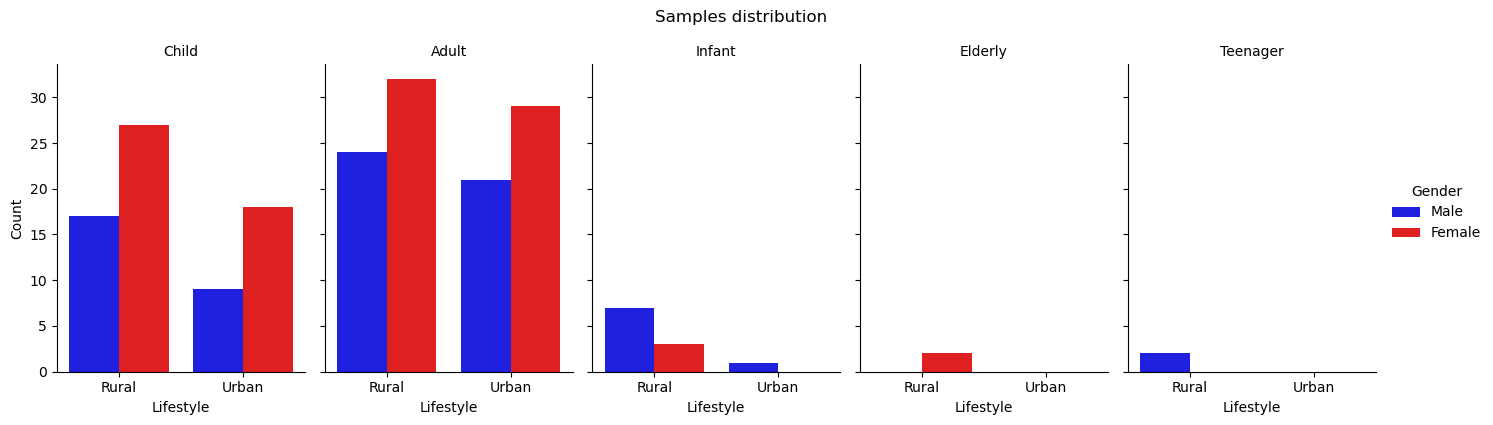

In [8]:
custom_palette = {'Male': 'blue', 'Female': 'red'}  
g = sns.catplot(x='Lifestyle', hue='Gender', col='Age group', 
                data=metadata, kind='count', height=4, aspect=0.7, palette=custom_palette)
g.set_axis_labels('Lifestyle', 'Count')
g.set_titles('{col_name}')
g.fig.suptitle('Samples distribution', y=1.05)
# plt.savefig('../imgs/samples_distribution.png', dpi = 500)
plt.show()


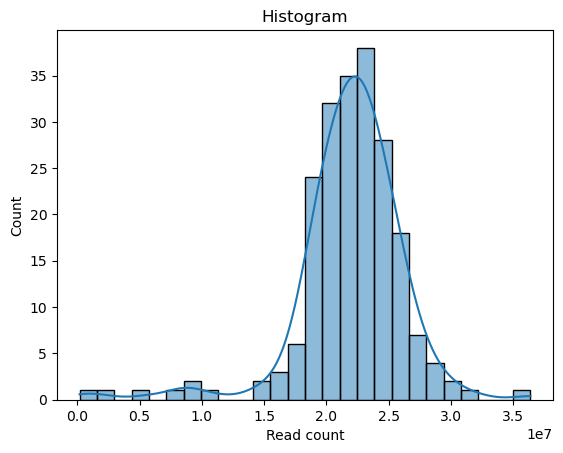

In [11]:
sns.histplot(metadata['Read count'], kde=True)
plt.xlabel('Read count')
plt.ylabel('Count')
plt.title('Histogram')
# plt.savefig('../imgs/reads_histogram.png', dpi = 500)
plt.show()

In [20]:
metadata.sort_values('Read count').head(2)

,Run,Lane,Sample,Supplier Name,Public Name,Read count,Sample.1,Study,Health state,Disease name,BMI,Antibiotics,Age,Age group,Gender,Lifestyle,Country,Continent
24,37082_3_16,37082_3#16,GI1_LA9438085,B21,B9/17,185470,37082_3_16,Latinbiota,Healthy,NaN,22.5,NaN,31.0,Adult,Female,Rural,Mexico,North America
37,37082_2_4,37082_2#4,GI1_LA9438025,C42,C41,1779530,37082_2_4,Latinbiota,Healthy,NaN,17.8,NaN,8.0,Child,Male,Urban,Mexico,North America


In [13]:
Q1 = metadata['Read count'].quantile(0.25)
Q3 = metadata['Read count'].quantile(0.75)

In [14]:
IQR = Q3 - Q1

# Step 3: Define the outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [15]:
outliers = metadata[(metadata['Read count'] < lower_bound) | (metadata['Read count'] > upper_bound)]

In [16]:
outliers

,Run,Lane,Sample,Supplier Name,Public Name,Read count,Sample.1,Study,Health state,Disease name,BMI,Antibiotics,Age,Age group,Gender,Lifestyle,Country,Continent
5,37082_3_4,37082_3#4,GI1_LA9438070,159,130,31944470,37082_3_4,Latinbiota,Healthy,NaN,22.4,NaN,35.0,Adult,Female,Rural,Mexico,North America
24,37082_3_16,37082_3#16,GI1_LA9438085,B21,B9/17,185470,37082_3_16,Latinbiota,Healthy,NaN,22.5,NaN,31.0,Adult,Female,Rural,Mexico,North America
29,37082_3_11,37082_3#11,GI1_LA9438079,62,51,5669548,37082_3_11,Latinbiota,Healthy,NaN,28.0,NaN,34.0,Adult,Female,Rural,Mexico,North America
33,37082_2_8,37082_2#8,GI1_LA9438033,C50,C49,36372476,37082_2_8,Latinbiota,Healthy,NaN,NaN,NaN,33.0,Adult,Male,Urban,Mexico,North America
36,37082_2_5,37082_2#5,GI1_LA9438026,C43,C42,8556292,37082_2_5,Latinbiota,Healthy,NaN,NaN,NaN,NaN,NaN,Female,Urban,Mexico,North America
37,37082_2_4,37082_2#4,GI1_LA9438025,C42,C41,1779530,37082_2_4,Latinbiota,Healthy,NaN,17.8,NaN,8.0,Child,Male,Urban,Mexico,North America
97,37035_7_23,37035_7#23,GI1_LA9825342,114,114,8502694,37035_7_23,Latinbiota,Healthy,NaN,NaN,NaN,NaN,NaN,NaN,Rural,Mexico,North America
150,37035_1_4,37035_1#4,GI1_LA9438113,125,135,11001358,37035_1_4,Latinbiota,Healthy,NaN,14.9,NaN,9.0,Child,Female,Rural,Mexico,North America
179,36703_3_6,36703_3#6,GI1_LA9438031,C48,C47,8934960,36703_3_6,Latinbiota,Healthy,NaN,NaN,NaN,4.0,Child,Male,Urban,Mexico,North America


In [17]:
rare = ['37082_3#16',
'37082_2#4',
'37035_2#22',
'37035_7#18',
'36703_3#20',
'36703_3#4']


In [20]:
metadata[metadata['Lane'].isin(rare)][['Lane', 'Read count', 'Health state', 'BMI', 'Age', 'Age group', 'Gender', 'Lifestyle']]

,Lane,Read count,Health state,BMI,Age,Age group,Gender,Lifestyle
24,37082_3#16,185470,Healthy,22.5,31.0,Adult,Female,Rural
37,37082_2#4,1779530,Healthy,17.8,8.0,Child,Male,Urban
103,37035_7#18,22573852,Healthy,NaN,NaN,NaN,NaN,Rural
130,37035_2#22,24769900,Healthy,NaN,8.0,Child,Male,Urban
181,36703_3#4,20667418,Healthy,NaN,NaN,NaN,NaN,Urban
195,36703_3#20,16695310,Healthy,14.6,7.0,Child,Female,Rural
